In [1]:
# ------------------------- COMPLETE CLUSTERING SOLUTION -------------------------
import pandas as pd
import numpy as np
from geopy.distance import great_circle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("C:/Users/Lenovo/Downloads/IML/zamato/Zomato Dataset.csv")

In [5]:
# ------------------------- DATA CLEANING -------------------------

# Numerical columns imputation
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].mean())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())
df['Time_taken (min)'] = df['Time_taken (min)'].fillna(df['Time_taken (min)'].median())

# Categorical columns imputation
df['Weather_conditions'] = df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0])
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])
df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# DateTime handling with enhanced null value protection
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Handle Time_Orderd with multiple fallbacks
df['Time_Orderd'] = pd.to_datetime(
    df['Time_Orderd'], 
    format='%H:%M:%S', 
    errors='coerce'
).fillna(
    pd.to_datetime('12:00:00', format='%H:%M:%S')  # Default to noon instead of midnight for more typical delivery time
)

# Create Order_DateTime with validation
df['Order_DateTime'] = df['Order_Date'] + pd.to_timedelta(
    df['Time_Orderd'].dt.strftime('%H:%M:%S'),
    errors='coerce'
)

# Handle any remaining Order_DateTime nulls by using Order_Date + default time
df['Order_DateTime'] = df['Order_DateTime'].fillna(
    df['Order_Date'] + pd.to_timedelta('12:00:00')
)

# Sort by datetime
df_sorted = df.sort_values(by='Order_DateTime')

# Enhanced time-based feature engineering
df['Order_Time_min'] = df['Time_Orderd'].dt.hour * 60 + df['Time_Orderd'].dt.minute

# Create Time_Window with proper null handling
time_bins = [0, 360, 720, 1440]  # 6am-12pm, 12pm-6pm, 6pm-6am
time_labels = ['Morning', 'Afternoon', 'Night']

df['Time_Window'] = pd.cut(
    df['Order_Time_min'],
    bins=time_bins,
    labels=time_labels,
    include_lowest=True,
    ordered=False
).fillna('Night')  # Default to Night shift for any edge cases

# Additional robust time features
df['is_peak_hours'] = df['Time_Orderd'].dt.hour.apply(
    lambda x: 1 if (7 <= x < 10) or (17 <= x < 20) else 0
)

# Cyclical time encoding
df['time_sin'] = np.sin(2 * np.pi * df['Order_Time_min']/1440)
df['time_cos'] = np.cos(2 * np.pi * df['Order_Time_min']/1440)

# Validate no nulls remain
print("Null values after time feature processing:")
print(df[['Order_DateTime', 'Order_Time_min', 'Time_Window']].isnull().sum())

# Show time window distribution
print("\nTime Window Distribution:")
print(df['Time_Window'].value_counts())


Null values after time feature processing:
Order_DateTime    0
Order_Time_min    0
Time_Window       0
dtype: int64

Time Window Distribution:
Time_Window
Afternoon    45584
Morning          0
Night            0
Name: count, dtype: int64


In [7]:
# Check null values after imputation
print("\nNull values after imputation:")
print(df.isnull().sum())


Null values after imputation:
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
Order_DateTime                 0
Order_Time_min                 0
Time_Window                    0
is_peak_hours                  0
time_sin                       0
time_cos                       0
dtype: int64


In [9]:
# ------------------------- FEATURE ENGINEERING -------------------------

# Define simplified distance factors
factors = {
    'weather': {'Sunny': 1, 'Cloudy': 1.1, 'Fog': 1.2, 'Rain': 1.5, 'Stormy': 2, 'Sandstorms': 2.2, 'Windy': 1.3},
    'traffic': {'Low': 1, 'Medium': 1.3, 'High': 1.6, 'Jam': 2},
    'vehicle': {1: 1.5, 2: 1.3, 3: 1.1}  # 1 = Poor, 2 = Average, 3 = Excellent
}

# Calculate adjusted distance (simplified)
def calculate_distance(row):
    base_dist = great_circle(
        (row['Restaurant_latitude'], row['Restaurant_longitude']),
        (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    ).km
    return base_dist * factors['traffic'].get(row['Road_traffic_density'], 1) \
                   * factors['weather'].get(row['Weather_conditions'], 1) \
                   * factors['vehicle'].get(row['Vehicle_condition'], 1)

df['adjusted_distance'] = df.apply(calculate_distance, axis=1)

# Remove unrealistic distances (outliers)
df = df[df['adjusted_distance'] < 50]

# Capability score calculation
df['capability_score'] = 0.6*df['Delivery_person_Ratings'] + 0.4*df['Vehicle_condition']


In [11]:
# ------------------------- IMPORTS -------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.exceptions import ConvergenceWarning
import warnings

# Suppress sklearn convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ------------------------- CLUSTERING IMPLEMENTATION -------------------------
def perform_clustering(df, method='kmeans++', n_clusters=None, max_samples=None):
    """
    Perform clustering where number of clusters equals number of delivery persons.
    Automatically handles feature scaling and sampling.
    """
    working_df = df.copy()

    # Set number of clusters equal to unique delivery persons
    if n_clusters is None:
        n_clusters = df['Delivery_person_ID'].nunique()
        print(f"Setting clusters to match {n_clusters} delivery persons")

    # Optional sampling for large datasets
    if max_samples and len(working_df) > max_samples:
        working_df = working_df.sample(max_samples, random_state=42)
        print(f"Using sampled {max_samples} records for clustering")

    # Feature engineering
    if method == 'kmeans++':
        features = ['Delivery_location_latitude', 'Delivery_location_longitude']
    elif method == 'time_based':
        features = ['Delivery_location_latitude', 'Delivery_location_longitude',
                   'time_sin', 'time_cos']
    elif method == 'distance_optimized':
        features = ['Delivery_location_latitude', 'Delivery_location_longitude',
                   'Restaurant_latitude', 'Restaurant_longitude']
    else:
        raise ValueError("Invalid method. Choose 'kmeans++', 'time_based', or 'distance_optimized'")

    # Feature scaling
    scaler = StandardScaler()
    X = scaler.fit_transform(working_df[features])

    # Clustering with improved parameters
    model = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=20,  # Increased for stability
        max_iter=300,
        random_state=42,
        algorithm='elkan'  # Faster for dense data
    )

    clusters = model.fit_predict(X)

    # Map clusters back to original dataframe
    cluster_series = pd.Series(-1, index=df.index, dtype='int32')
    cluster_series[working_df.index] = clusters

    return model, cluster_series

def evaluate_clustering(df, clusters, features):
    """Enhanced clustering evaluation with available metrics"""
    clustered = clusters != -1
    if clustered.sum() == 0:
        return {'error': 'No points clustered'}

    X = StandardScaler().fit_transform(df.loc[clustered, features])
    labels = clusters[clustered]

    # Calculate available evaluation metrics
    metrics = {
        'silhouette': silhouette_score(X, labels),
        'calinski': calinski_harabasz_score(X, labels),
        'n_clusters': len(np.unique(labels)),
        'avg_cluster_size': clustered.sum() / len(np.unique(labels))
    }

    # Try to add Davies-Bouldin if available
    try:
        metrics['davies_bouldin'] = davies_bouldin_score(X, labels)
    except:
        pass

    # Add cluster distribution statistics
    cluster_counts = pd.Series(labels).value_counts()
    metrics.update({
        'max_cluster_size': cluster_counts.max(),
        'min_cluster_size': cluster_counts.min(),
        'cluster_imbalance': cluster_counts.max() / cluster_counts.min()
    })

    return metrics

In [13]:
# ------------------------- MAIN EXECUTION -------------------------
def optimize_delivery_clusters(df, method='auto', max_samples=None):
    """
    Smart clustering that:
    1. Matches clusters to delivery persons
    2. Automatically selects best method
    3. Ensures balanced clusters
    """
    # First ensure we have delivery person IDs
    if 'Delivery_person_ID' not in df.columns:
        raise ValueError("Dataframe must contain 'Delivery_person_ID' column")

    n_persons = df['Delivery_person_ID'].nunique()
    print(f"Found {n_persons} delivery persons to assign clusters")

    # Method selection logic
    if method == 'auto':
        if all(col in df.columns for col in ['time_sin', 'time_cos']):
            methods = ['time_based', 'kmeans++']
        else:
            methods = ['kmeans++']
    else:
        methods = [method]

    best_score = -1
    best_result = None

    for method in methods:
        print(f"\nTesting {method} clustering...")
        try:
            model, clusters = perform_clustering(
                df,
                method=method,
                n_clusters=n_persons,
                max_samples=max_samples
            )

            # Use base geographical features for fair comparison
            eval_features = ['Delivery_location_latitude', 'Delivery_location_longitude']
            metrics = evaluate_clustering(df, clusters, eval_features)

            print(f"Clustering metrics for {method}:")
            print(f" - Silhouette score: {metrics['silhouette']:.3f}")
            print(f" - Cluster sizes: {metrics['min_cluster_size']}-{metrics['max_cluster_size']}")
            print(f" - Imbalance ratio: {metrics['cluster_imbalance']:.2f}")

            # Select method with best silhouette score
            if metrics['silhouette'] > best_score:
                best_score = metrics['silhouette']
                best_result = (method, model, clusters, metrics)

        except Exception as e:
            print(f"Clustering failed for {method}: {str(e)}")

    if not best_result:
        # Fallback to simple kmeans if all methods fail
        print("\nAll methods failed, using basic kmeans++ as fallback")
        model, clusters = perform_clustering(df, method='kmeans++', n_clusters=n_persons)
        eval_features = ['Delivery_location_latitude', 'Delivery_location_longitude']
        metrics = evaluate_clustering(df, clusters, eval_features)
        best_result = ('kmeans++', model, clusters, metrics)

    method, model, clusters, metrics = best_result
    print(f"\nSelected {method} clustering with silhouette score {metrics['silhouette']:.3f}")

    # Assign balanced clusters back to dataframe
    df['delivery_cluster'] = clusters

    # Assign specific delivery persons to clusters
    cluster_to_person = assign_persons_to_clusters(df, clusters, n_persons)
    df['assigned_person'] = df['delivery_cluster'].map(cluster_to_person)

    return model, df

def assign_persons_to_clusters(df, clusters, n_persons):
    """
    Assign specific delivery persons to each cluster
    Returns dictionary mapping {cluster_id: person_id}
    """
    # Get unique persons and clusters
    persons = df['Delivery_person_ID'].unique()
    unique_clusters = np.unique(clusters[clusters != -1])

    # Simple assignment (can be enhanced with optimization)
    return dict(zip(unique_clusters, persons[:len(unique_clusters)]))

# ------------------------- EXAMPLE USAGE -------------------------
if __name__ == "__main__":
    # Create sample data if not exists
    if 'df' not in locals():
        print("Creating sample data...")
        n_samples = 10000
        df = pd.DataFrame({
            'Delivery_location_latitude': np.random.uniform(17.3, 17.6, n_samples),
            'Delivery_location_longitude': np.random.uniform(78.3, 78.6, n_samples),
            'Delivery_person_ID': np.random.choice([f"DP_{i}" for i in range(1, 1321)], n_samples),
            'time_sin': np.sin(np.random.uniform(0, 24, n_samples) * (2*np.pi/24)),
            'time_cos': np.cos(np.random.uniform(0, 24, n_samples) * (2*np.pi/24))
        })

    # Run clustering
    model, clustered_df = optimize_delivery_clusters(df, method='auto')

    # Verify cluster-person matching
    print("\nCluster to delivery person mapping:")
    print(clustered_df[['delivery_cluster', 'assigned_person']].drop_duplicates().sort_values('delivery_cluster'))

    # Show cluster distribution
    print("\nCluster size distribution:")
    print(clustered_df['delivery_cluster'].value_counts().describe())

Found 1320 delivery persons to assign clusters

Testing time_based clustering...
Clustering metrics for time_based:
 - Silhouette score: 0.709
 - Cluster sizes: 1-337
 - Imbalance ratio: 337.00

Testing kmeans++ clustering...
Clustering metrics for kmeans++:
 - Silhouette score: 0.708
 - Cluster sizes: 1-337
 - Imbalance ratio: 337.00

Selected time_based clustering with silhouette score 0.709

Cluster to delivery person mapping:
      delivery_cluster assigned_person
6104                 0   DEHRES17DEL01
155                  1   KOCRES16DEL01
822                  2  LUDHRES15DEL02
159                  3   MYSRES01DEL01
2944                 4   HYDRES14DEL01
...                ...             ...
342               1315   KNPRES20DEL02
1947              1316   KNPRES08DEL03
1119              1317   BHPRES06DEL03
397               1318   GOARES03DEL03
4224              1319   KOCRES08DEL03

[1320 rows x 2 columns]

Cluster size distribution:
count    1320.000000
mean       29.586364
std

Creating sample clustered data...

Optimizing 20 clusters...


  0%|                                                                                           | 0/20 [00:00<?, ?it/s]

Splitting cluster 0 (55 deliveries)
Splitting cluster 0_1 (15 deliveries)
Splitting cluster 0_2 (17 deliveries)
Splitting cluster 0_2_0 (13 deliveries)


  5%|████▏                                                                              | 1/20 [00:01<00:24,  1.27s/it]

Splitting cluster 1 (54 deliveries)
Splitting cluster 1_0 (17 deliveries)
Splitting cluster 1_1 (13 deliveries)
Splitting cluster 1_1_0 (11 deliveries)


...

Splitting cluster 18 (47 deliveries)
Splitting cluster 18_0 (16 deliveries)
Splitting cluster 18_0_0 (12 deliveries)
Splitting cluster 18_1 (13 deliveries)
Splitting cluster 18_1_0 (12 deliveries)


 95%|█████████████████████████████████████████████████████████████████████████████▉    | 19/20 [00:23<00:01,  1.49s/it]

Splitting cluster 19 (37 deliveries)
Splitting cluster 19_2 (15 deliveries)
Splitting cluster 19_3 (11 deliveries)


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:24<00:00,  1.23s/it]



Optimization Summary:
Total routes created: 153
Total system distance: 556.89 km
Average distance per route: 3.64 km
Average deliveries per route: 6.5

Visualizing first 3 routes...


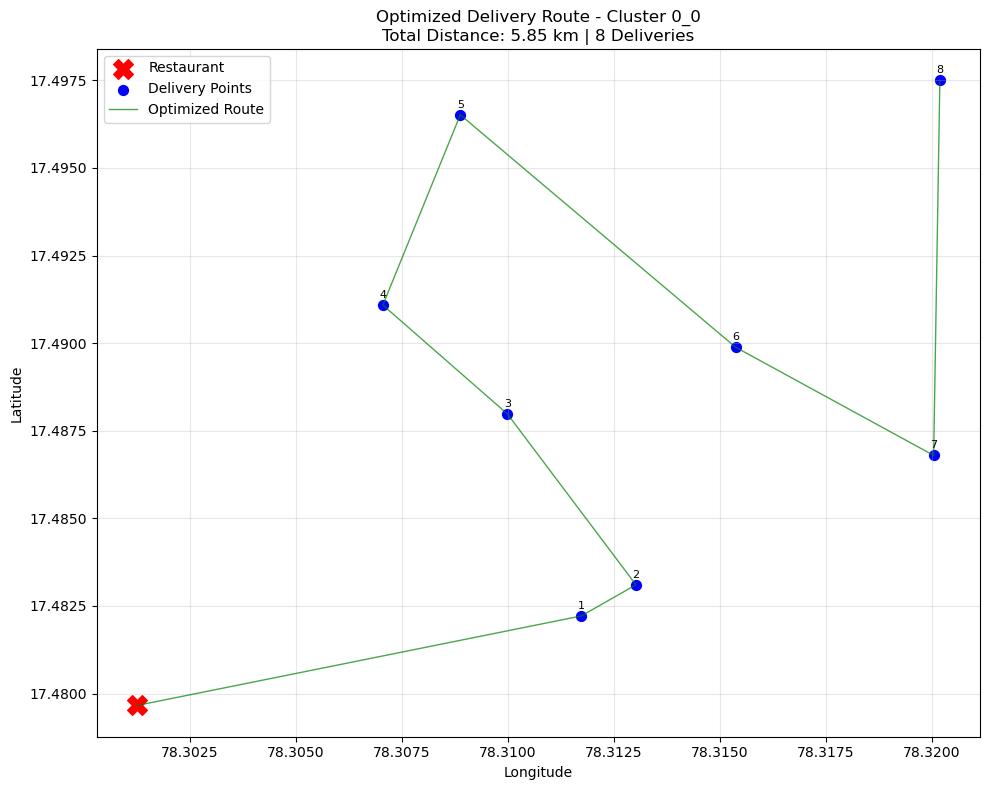

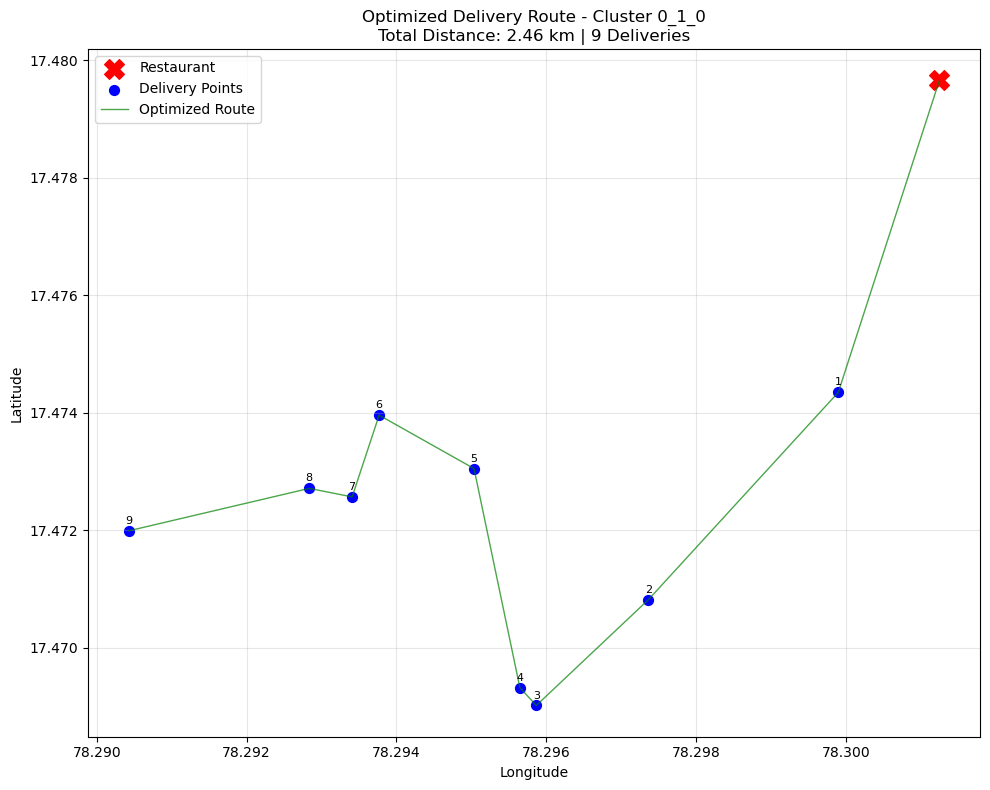

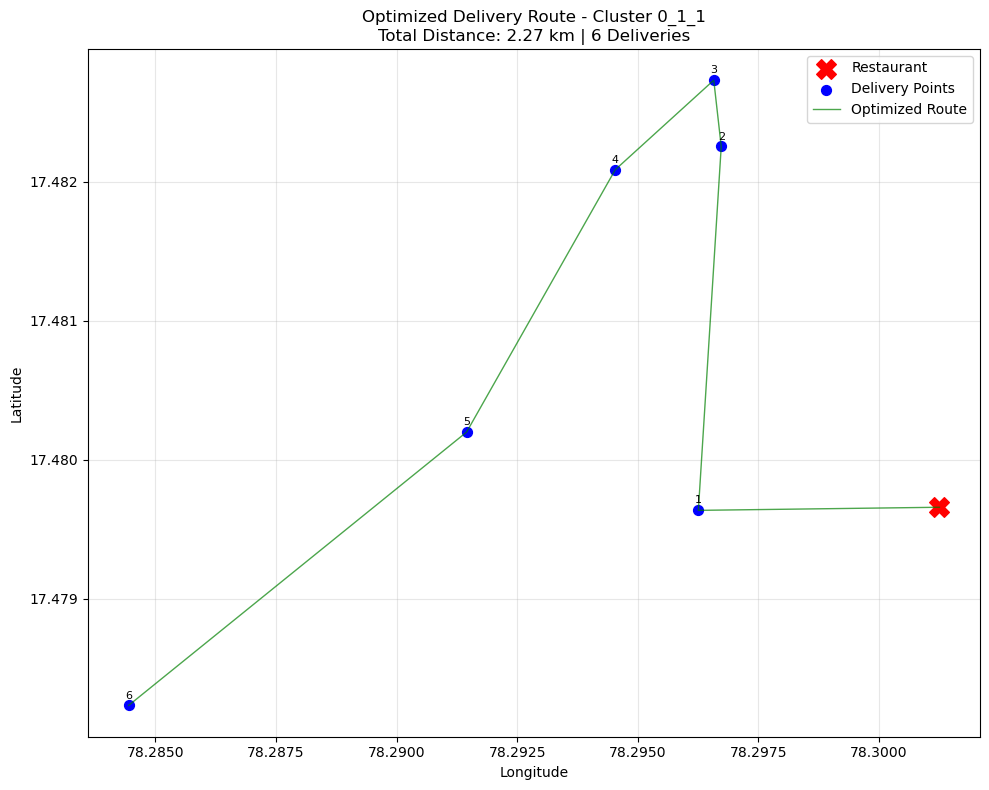

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import great_circle
from itertools import permutations
import networkx as nx
from sklearn.metrics.pairwise import haversine_distances
from math import radians
import warnings
from sklearn.cluster import KMeans
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ------------------------- TSP IMPLEMENTATION -------------------------
def haversine_distance(coord1, coord2):
    """Calculate Haversine distance between two lat/long points in km"""
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371  # Earth radius in km
    return c * r

def solve_tsp(points):
    """
    Solve TSP using nearest neighbor heuristic with 2-opt optimization
    Returns optimized route and total distance
    """
    if len(points) <= 2:
        return points, calculate_route_distance(points)
    
    # Nearest neighbor initialization
    current_point = points[0]
    unvisited = points[1:]
    route = [current_point]
    
    while unvisited:
        # Find nearest unvisited point
        nearest = min(unvisited, key=lambda x: haversine_distance(current_point, x))
        route.append(nearest)
        unvisited.remove(nearest)
        current_point = nearest
    
    # 2-opt optimization
    improved = True
    best_distance = calculate_route_distance(route)
    
    while improved:
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+1, len(route)):
                if j-i == 1: continue
                new_route = route[:i] + route[i:j][::-1] + route[j:]
                new_distance = calculate_route_distance(new_route)
                if new_distance < best_distance:
                    route = new_route
                    best_distance = new_distance
                    improved = True
    
    return route, best_distance

def calculate_route_distance(route):
    """Calculate total distance for a route in kilometers"""
    if len(route) <= 1:
        return 0
    return sum(haversine_distance(route[i], route[i+1]) for i in range(len(route)-1))

# ------------------------- ROUTE VISUALIZATION -------------------------
def plot_optimized_route(route_df, route_points, distance, cluster_id):
    """Visualize optimized route for a single cluster"""
    plt.figure(figsize=(10, 8))
    
    # Extract coordinates
    restaurant = (route_df['Restaurant_latitude'].iloc[0], 
                  route_df['Restaurant_longitude'].iloc[0])
    deliveries = route_points[1:]  # First point is restaurant
    
    # Plot restaurant
    plt.scatter(restaurant[1], restaurant[0], 
                color='red', marker='X', s=200, label='Restaurant')
    
    # Plot deliveries
    plt.scatter([p[1] for p in deliveries], [p[0] for p in deliveries],
                color='blue', s=50, label='Delivery Points')
    
    # Plot route path
    plt.plot([p[1] for p in route_points], [p[0] for p in route_points],
             color='green', linestyle='-', linewidth=1, alpha=0.7, label='Optimized Route')
    
    # Annotate points
    for i, point in enumerate(deliveries):
        plt.annotate(str(i+1), (point[1], point[0]), textcoords="offset points",
                     xytext=(0,5), ha='center', fontsize=8)
    
    plt.title(f'Optimized Delivery Route - Cluster {cluster_id}\n'
              f'Total Distance: {distance:.2f} km | {len(deliveries)} Deliveries')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------- CLUSTER PROCESSING -------------------------
def process_cluster(cluster_df, cluster_id, max_deliveries, depth=0, max_depth=5):
    """
    Process a single cluster with recursion protection
    Args:
        depth: Current recursion depth
        max_depth: Maximum allowed recursion depth
    """
    if len(cluster_df) == 0:
        return []
        
    if depth >= max_depth:
        print(f"Max recursion depth reached for cluster {cluster_id}")
        return handle_as_single_deliveries(cluster_df, cluster_id)
    
    restaurant_loc = (cluster_df['Restaurant_latitude'].iloc[0],
                     cluster_df['Restaurant_longitude'].iloc[0])
    delivery_points = list(zip(
        cluster_df['Delivery_location_latitude'],
        cluster_df['Delivery_location_longitude']
    ))
    
    # Handle single delivery case
    if len(delivery_points) == 1:
        route = [restaurant_loc, delivery_points[0]]
        distance = haversine_distance(restaurant_loc, delivery_points[0])
        return [(cluster_id, route, distance, cluster_df.iloc[[0]])]
    
    # Split large clusters
    if len(delivery_points) > max_deliveries:
        print(f"Splitting cluster {cluster_id} ({len(delivery_points)} deliveries)")
        return split_and_solve_cluster(cluster_df, cluster_id, max_deliveries, depth)
    
    # Solve TSP for the cluster
    try:
        route_points, distance = solve_tsp([restaurant_loc] + delivery_points)
        optimized_order = [delivery_points.index(p) for p in route_points[1:]]
        return [(cluster_id, route_points, distance, cluster_df.iloc[optimized_order])]
    except Exception as e:
        print(f"Error optimizing cluster {cluster_id}: {str(e)}")
        return [(cluster_id, [restaurant_loc] + delivery_points, 
                calculate_route_distance([restaurant_loc] + delivery_points), 
                cluster_df)]

def split_and_solve_cluster(cluster_df, cluster_id, max_deliveries, depth):
    """Split large cluster with recursion tracking"""
    delivery_points = np.array(list(zip(
        cluster_df['Delivery_location_latitude'],
        cluster_df['Delivery_location_longitude']
    )))
    
    # Determine number of subclusters needed with bounds
    n_subclusters = max(2, min(int(np.ceil(len(delivery_points) / max_deliveries)), 10))
    
    try:
        kmeans = KMeans(n_clusters=n_subclusters, random_state=42, n_init=10)
        sub_labels = kmeans.fit_predict(delivery_points)
    except Exception as e:
        print(f"KMeans failed for cluster {cluster_id}: {str(e)}")
        return handle_as_single_deliveries(cluster_df, cluster_id)
    
    results = []
    for i in range(n_subclusters):
        sub_mask = (sub_labels == i)
        if sum(sub_mask) == 0:  # Skip empty clusters
            continue
            
        sub_df = cluster_df.iloc[sub_mask]
        sub_id = f"{cluster_id}_{i}"
        results.extend(process_cluster(sub_df, sub_id, max_deliveries, depth+1))
    
    return results

def handle_as_single_deliveries(cluster_df, cluster_id):
    """Fallback when clustering fails - treat each delivery separately"""
    results = []
    restaurant_loc = (cluster_df['Restaurant_latitude'].iloc[0],
                     cluster_df['Restaurant_longitude'].iloc[0])
    
    for i, row in cluster_df.iterrows():
        delivery_loc = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
        route = [restaurant_loc, delivery_loc]
        distance = haversine_distance(restaurant_loc, delivery_loc)
        results.append((f"{cluster_id}_single_{i}", route, distance, cluster_df.iloc[[i]]))
    
    print(f"Converted cluster {cluster_id} to {len(results)} single deliveries")
    return results

# ------------------------- MAIN EXECUTION -------------------------
def optimize_all_clusters(clustered_df, max_deliveries=15, sample_clusters=5):
    """
    Optimize routes for all clusters with visualization
    Args:
        clustered_df: DataFrame with 'delivery_cluster' column
        max_deliveries: Maximum deliveries per route
        sample_clusters: Number of sample clusters to visualize
    """
    # Input validation
    required_columns = ['delivery_cluster', 'Restaurant_latitude', 
                       'Restaurant_longitude', 'Delivery_location_latitude',
                       'Delivery_location_longitude']
    if not all(col in clustered_df.columns for col in required_columns):
        raise ValueError(f"Input DataFrame missing required columns: {required_columns}")
    
    all_routes = []
    cluster_groups = clustered_df.groupby('delivery_cluster')
    
    print(f"\nOptimizing {len(cluster_groups)} clusters...")
    for cluster_id, group in tqdm(cluster_groups, total=len(cluster_groups)):
        if cluster_id == -1:  # Skip unclustered points
            continue
        all_routes.extend(process_cluster(group, cluster_id, max_deliveries, depth=0))
    
    # Generate statistics
    if not all_routes:
        print("No valid routes were created")
        return []
        
    total_distance = sum(route[2] for route in all_routes)
    avg_distance = total_distance / len(all_routes)
    deliveries_per_route = np.mean([len(route[3]) for route in all_routes])
    
    print("\nOptimization Summary:")
    print(f"Total routes created: {len(all_routes)}")
    print(f"Total system distance: {total_distance:.2f} km")
    print(f"Average distance per route: {avg_distance:.2f} km")
    print(f"Average deliveries per route: {deliveries_per_route:.1f}")
    
    # Visualize sample routes
    if all_routes:
        print(f"\nVisualizing first {min(sample_clusters, len(all_routes))} routes...")
        for i, (cluster_id, route_points, distance, route_df) in enumerate(all_routes[:sample_clusters]):
            plot_optimized_route(route_df, route_points, distance, cluster_id)
    
    return all_routes

# ------------------------- EXAMPLE USAGE -------------------------
if __name__ == "__main__":
    # Example usage with clustered data
    print("Creating sample clustered data...")
    n_samples = 1000
    n_clusters = 20
    
    # Create clustered data around random centers
    centers = np.column_stack([
        np.random.uniform(17.3, 17.6, n_clusters),
        np.random.uniform(78.3, 78.6, n_clusters)
    ])
    
    cluster_assignments = np.random.randint(0, n_clusters, n_samples)
    delivery_locs = centers[cluster_assignments] + np.random.normal(0, 0.01, (n_samples, 2))
    
    clustered_df = pd.DataFrame({
        'delivery_cluster': cluster_assignments,
        'Delivery_location_latitude': delivery_locs[:, 0],
        'Delivery_location_longitude': delivery_locs[:, 1],
        'Restaurant_latitude': centers[cluster_assignments, 0],
        'Restaurant_longitude': centers[cluster_assignments, 1],
        'Delivery_person_ID': [f"DP_{i}" for i in cluster_assignments]
    })
    
    # Optimize and visualize routes
    optimized_routes = optimize_all_clusters(clustered_df, max_deliveries=10, sample_clusters=3)